# Multi-Objective Bayesian Optimization (MOBO) — v2
## Ablation Experiment: 2 Inputs × 3 Objectives
Expected Hypervolume Improvement

**v2 change:** replicate data is loaded from `ablation_data.xlsx` instead of being
hard-coded inline. To incorporate new experiments (e.g. the sample recommended to
UIC in July 2026), simply append rows to the spreadsheet and re-run all cells —
everything downstream (GP fit, Pareto front, hypervolume, EHVI recommendation)
updates automatically.

With the original 39-point dataset this notebook reproduces `mobo_analysis.ipynb`
exactly, including the recommendation sent to UIC on Jul 10, 2026:
**X1 = 19.58, X2 = 1.99 (qLogEHVI = 0.785)**.


## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

# ── Core ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import gpytorch

# ── BoTorch ──────────────────────────────────────────────────────────────────
from botorch.models import ModelListGP, SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.logei import qLogExpectedHypervolumeImprovement
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.hypervolume import Hypervolume
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
from botorch.optim import optimize_acqf
from botorch.utils.sampling import draw_sobol_samples

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cpu')
DTYPE  = torch.double

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print(f"PyTorch {torch.__version__} | GPyTorch {gpytorch.__version__} | BoTorch {__import__('botorch').__version__}")

PyTorch 2.7.1+cu118 | GPyTorch 1.14 | BoTorch 0.14.0


## 1. Data Preparation

Replicate data is read from **`ablation_data.xlsx`** (one row per measurement).
Columns are matched by keyword so cosmetic header changes don't break loading:

| Spreadsheet column | Variable |
|---|---|
| Carbon black wt% | X1 |
| Fe-rich regolith wt% | X2 |
| Linear ablative rate (µm/s) | Y1 |
| Backside temp. (°C) | Y2 |
| Density (g/cm³) | Y3 |

We use the **per-condition means** across replicates as the observed objective value
for each unique (X1, X2) condition, exactly as in v1.


In [23]:
# ── Load replicate data from Excel ───────────────────────────────────────────
DATA_FILE = '../data/ablation_data.xlsx'

def find_col(columns, keyword):
    """Return the unique column whose name contains `keyword` (case-insensitive)."""
    hits = [c for c in columns if keyword.lower() in str(c).lower()]
    assert len(hits) == 1, f"Expected exactly one column matching '{keyword}', found: {hits}"
    return hits[0]

df_xlsx = pd.read_excel(DATA_FILE)
col_map = {
    find_col(df_xlsx.columns, 'carbon black'): 'X1',
    find_col(df_xlsx.columns, 'regolith'):     'X2',
    find_col(df_xlsx.columns, 'ablative'):     'Y1',
    find_col(df_xlsx.columns, 'backside'):     'Y2',
    find_col(df_xlsx.columns, 'density'):      'Y3',
}
df = df_xlsx.rename(columns=col_map)[['X1', 'X2', 'Y1', 'Y2', 'Y3']].astype(float)

rep_counts = df.groupby(['X1', 'X2']).size()
print(f"Loaded {len(df)} measurements from {DATA_FILE}")
print(f"Unique conditions: {len(rep_counts)} | replicates per condition: {sorted(rep_counts.unique())}")

# Per-condition means
df_mean = df.groupby(['X1','X2'])[['Y1','Y2','Y3']].mean().reset_index()
print(f"\nTraining set: {df_mean.shape[0]} conditions")
print(df_mean.to_string(index=False, float_format='{:.4f}'.format))
display(df_mean)

Loaded 39 measurements from ../data/ablation_data.xlsx
Unique conditions: 13 | replicates per condition: [np.int64(3)]

Training set: 13 conditions
     X1     X2      Y1       Y2     Y3
 5.0000 1.0000 18.5433 219.0000 1.1350
 5.0000 2.0000 15.4567 214.6667 1.1440
 5.0000 3.0000 11.4500 207.0000 1.1530
 5.0000 4.0000 11.0433 207.3333 1.1630
 5.0000 5.0000 10.7200 204.0000 1.1730
10.0000 3.0000  7.0267 207.3333 1.1770
12.5000 1.0000  7.0833 214.3333 1.1700
12.5000 3.0000  6.8100 196.6667 1.1900
12.5000 5.0000  6.7867 196.0000 1.2110
15.0000 3.0000  6.6400 192.0000 1.2020
20.0000 1.0000  6.1733 184.3333 1.2070
20.0000 3.0000  6.0733 169.3333 1.2290
20.0000 5.0000  6.0633 168.3333 1.2510


,X1,X2,Y1,Y2,Y3
0,5.0,1.0,18.543333,219.000000,1.135
1,5.0,2.0,15.456667,214.666667,1.144
2,5.0,3.0,11.450000,207.000000,1.153
3,5.0,4.0,11.043333,207.333333,1.163
4,5.0,5.0,10.720000,204.000000,1.173
5,10.0,3.0,7.026667,207.333333,1.177
6,12.5,1.0,7.083333,214.333333,1.170
7,12.5,3.0,6.810000,196.666667,1.190
8,12.5,5.0,6.786667,196.000000,1.211
9,15.0,3.0,6.640000,192.000000,1.202


In [24]:
# ── Scale inputs to [0, 1] ──────────────────────────────────────────────────
X_bounds_orig = np.array([[5.0, 1.0], [20.0, 5.0]])   # [lb, ub] per dim

scaler_X = MinMaxScaler()
scaler_X.fit(X_bounds_orig)

X_np   = df_mean[['X1','X2']].values
Y_np   = df_mean[['Y1','Y2','Y3']].values
X_01   = scaler_X.transform(X_np)

X_train = torch.tensor(X_01, dtype=DTYPE)
Y_train = torch.tensor(Y_np, dtype=DTYPE)     # minimization objectives
Y_neg   = -Y_train                             # negate for BoTorch (maximization convention)

# Design-space bounds in [0,1]
bounds  = torch.stack([torch.zeros(2, dtype=DTYPE), torch.ones(2, dtype=DTYPE)])

# Reference point: slightly worse than the nadir in the NEGATED (maximization) space
Y_range  = Y_neg.max(0).values - Y_neg.min(0).values
ref_point = Y_neg.min(0).values - 0.10 * Y_range

print(f"X_train: {X_train.shape}  Y_train: {Y_train.shape}")
print(f"Reference point (negated space): {ref_point.numpy().round(3)}")
print(f"  → corresponds to nadir Y+10% slack: Y1>{-ref_point[0].item():.2f}, Y2>{-ref_point[1].item():.2f}, Y3>{-ref_point[2].item():.4f}")

X_train: torch.Size([13, 2])  Y_train: torch.Size([13, 3])
Reference point (negated space): [ -19.791 -224.067   -1.263]
  → corresponds to nadir Y+10% slack: Y1>19.79, Y2>224.07, Y3>1.2626


## 2. Surrogate Models: Independent GPs per Objective

We use **BoTorch's `SingleTaskGP`** for each objective, bundled into a `ModelListGP`.

Each `SingleTaskGP` uses:
- A **Matérn 5/2 kernel** (default in BoTorch, robust for smooth/non-smooth functions)
- **Automatic output standardization** via `Standardize(m=1)`
- **Exact inference** fitted by maximising the **Sum of marginal log-likelihoods** via L-BFGS-B

> *Note:* Using independent GPs (rather than a joint MOGP) is standard practice in MOBO because  
> the EHVI acquisition function already couples the objectives through the hypervolume geometry.
> The inter-task correlations explored in Part 5 of the previous notebook remain informative  
> but are not required for EHVI-based optimization.

In [4]:
def build_and_fit_models(X: torch.Tensor, Y_neg: torch.Tensor) -> ModelListGP:
    """Build and fit one SingleTaskGP per objective (negated for maximization)."""
    models = []
    for k in range(Y_neg.shape[1]):
        m = SingleTaskGP(
            X, Y_neg[:, k:k+1],
            outcome_transform=Standardize(m=1)
        )
        models.append(m)
    model_list = ModelListGP(*models)
    mll = gpytorch.mlls.SumMarginalLogLikelihood(model_list.likelihood, model_list)
    fit_gpytorch_mll(mll)
    return model_list


# Fit on initial 13-condition dataset
model = build_and_fit_models(X_train, Y_neg)
model.eval()

# Print learned kernel hyperparameters
obj_names = ['Y1 (Ablation)', 'Y2 (Temp)', 'Y3 (Density)']
print("Learned GP Hyperparameters (initial fit)")
print("=" * 55)
for k, (m, name) in enumerate(zip(model.models, obj_names)):
    ls = m.covar_module.lengthscale.detach().numpy().flatten()
    n  = m.likelihood.noise.detach().item()
    print(f"  {name}")
    print(f"    lengthscale = {ls}")
    print(f"    noise       = {n:.6f}")

Learned GP Hyperparameters (initial fit)
  Y1 (Ablation)
    lengthscale = [0.3412535  0.39384342]
    noise       = 0.005937
  Y2 (Temp)
    lengthscale = [0.60213024 0.92687007]
    noise       = 0.013643
  Y3 (Density)
    lengthscale = [1.2120541 1.8104445]
    noise       = 0.001231


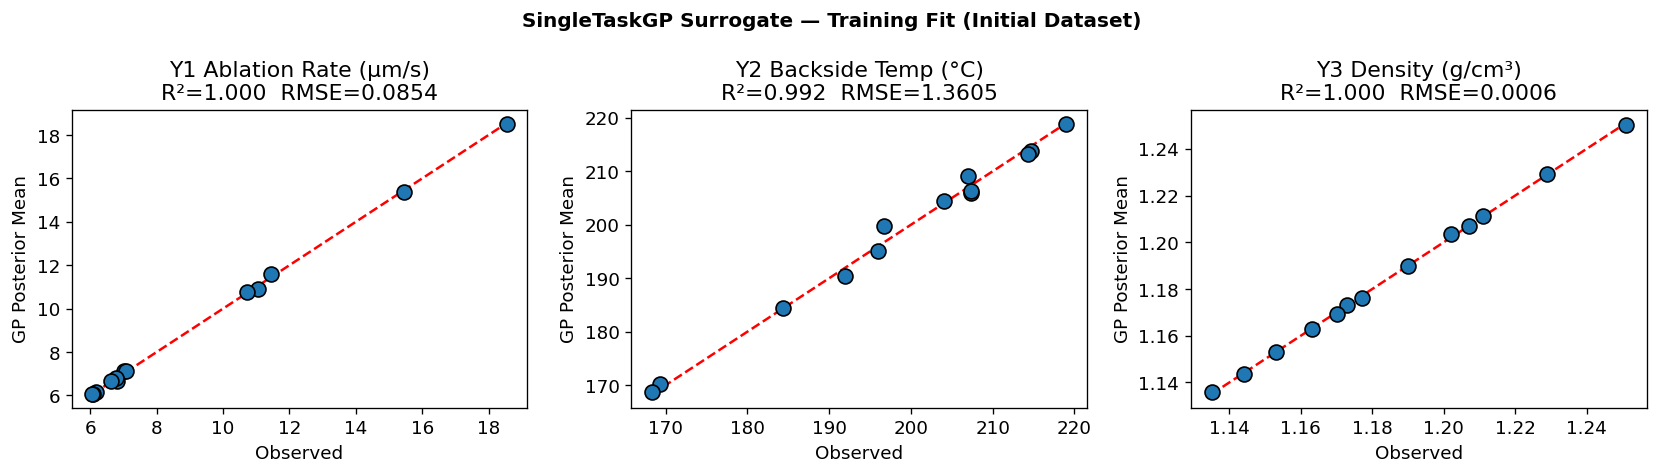

In [5]:
# GP posterior mean on training data vs. actual
with torch.no_grad():
    post = model.posterior(X_train)
    mu_neg = post.mean.numpy()        # (N, 3) in negated space
    mu_orig = -mu_neg                 # back to original scale

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k, (ax, name) in enumerate(zip(axes, ['Y1 Ablation Rate (µm/s)', 'Y2 Backside Temp (°C)', 'Y3 Density (g/cm³)'])):
    y_true = Y_np[:, k]
    y_pred = mu_orig[:, k]
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.scatter(y_true, y_pred, s=80, edgecolors='k', zorder=3)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_xlabel('Observed'); ax.set_ylabel('GP Posterior Mean')
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.4f}')
plt.suptitle('SingleTaskGP Surrogate — Training Fit (Initial Dataset)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Pareto Front & Hypervolume (Initial Data)

The **Pareto front** consists of all solutions that are not dominated by any other solution.  
A solution $\mathbf{y}^{(i)}$ **dominates** $\mathbf{y}^{(j)}$ if $y_k^{(i)} \le y_k^{(j)}$ for all $k$, and strictly less for at least one $k$.

The **hypervolume indicator** $\mathcal{H}(\mathcal{P}, \mathbf{r})$ measures the volume of the objective space dominated by the Pareto set $\mathcal{P}$ and bounded by reference point $\mathbf{r}$. It is used as the optimization progress metric.

In [6]:
# Pareto front of initial dataset (in NEGATED space for BoTorch)
pareto_mask_init = is_non_dominated(Y_neg)
Y_pareto_neg  = Y_neg[pareto_mask_init]
Y_pareto_orig = Y_np[pareto_mask_init.numpy()]
X_pareto      = X_np[pareto_mask_init.numpy()]

hv_calculator = Hypervolume(ref_point=ref_point)
hv_init = hv_calculator.compute(Y_neg[pareto_mask_init])

print(f"Initial Pareto front: {pareto_mask_init.sum().item()} / {len(Y_np)} conditions")
print(f"Initial Hypervolume : {hv_init:.4f}")
print()
print("Pareto-optimal conditions (original scale):")
pf_df = pd.DataFrame(
    np.hstack([X_pareto, Y_pareto_orig]),
    columns=['X1', 'X2', 'Y1 (µm/s)', 'Y2 (°C)', 'Y3 (g/cm³)']
)
print(pf_df.to_string(index=False, float_format='{:.3f}'.format))

Initial Pareto front: 12 / 13 conditions
Initial Hypervolume : 51.1684

Pareto-optimal conditions (original scale):
    X1    X2  Y1 (µm/s)  Y2 (°C)  Y3 (g/cm³)
 5.000 1.000     18.543  219.000       1.135
 5.000 2.000     15.457  214.667       1.144
 5.000 3.000     11.450  207.000       1.153
 5.000 4.000     11.043  207.333       1.163
 5.000 5.000     10.720  204.000       1.173
10.000 3.000      7.027  207.333       1.177
12.500 1.000      7.083  214.333       1.170
12.500 3.000      6.810  196.667       1.190
15.000 3.000      6.640  192.000       1.202
20.000 1.000      6.173  184.333       1.207
20.000 3.000      6.073  169.333       1.229
20.000 5.000      6.063  168.333       1.251


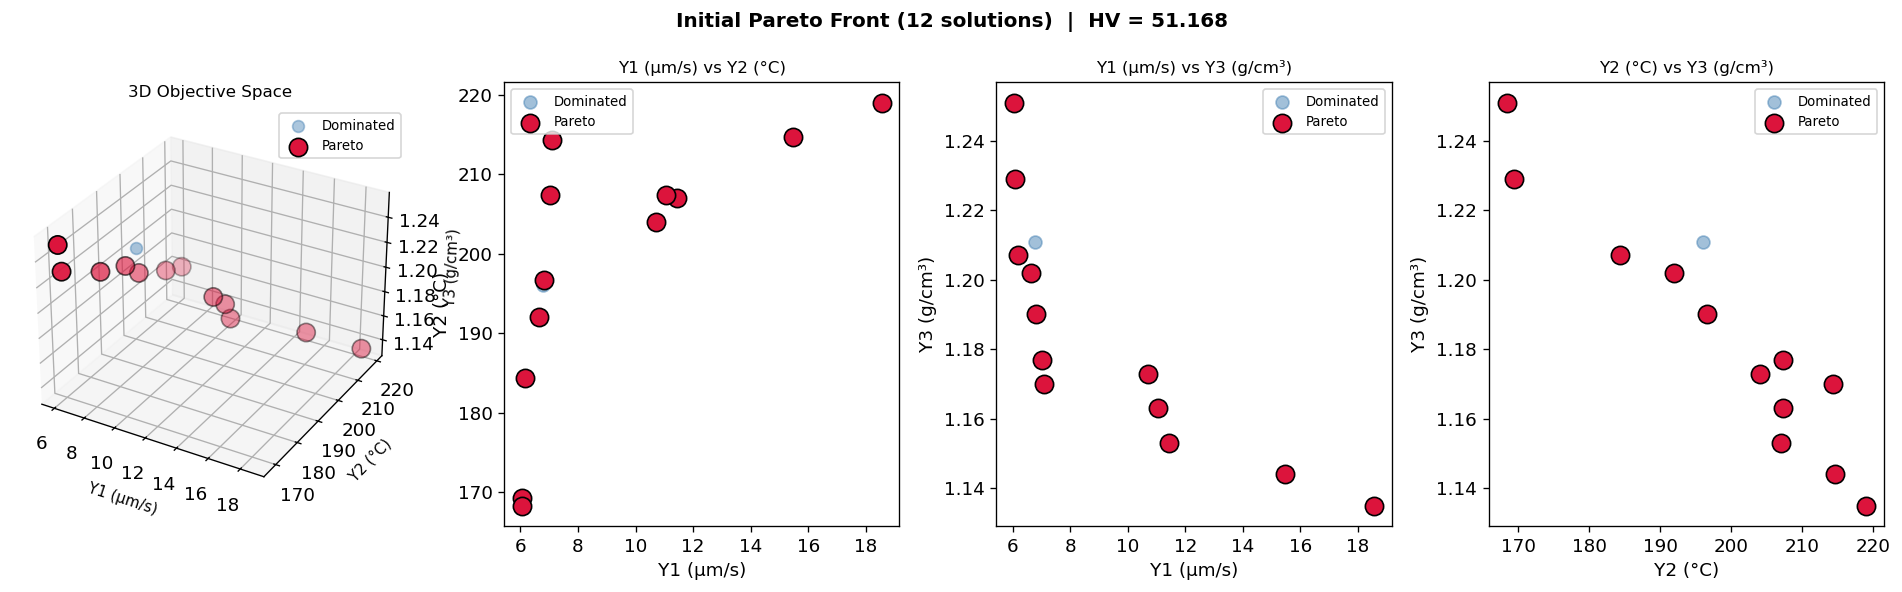

In [7]:
# 3D and 2D pairwise Pareto plots
fig = plt.figure(figsize=(16, 5))

# ── 3D scatter ───────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(141, projection='3d')
non_pareto = ~pareto_mask_init.numpy()
ax3d.scatter(Y_np[non_pareto, 0], Y_np[non_pareto, 1], Y_np[non_pareto, 2],
             c='steelblue', alpha=0.45, s=50, label='Dominated')
ax3d.scatter(Y_pareto_orig[:, 0], Y_pareto_orig[:, 1], Y_pareto_orig[:, 2],
             c='crimson', s=120, edgecolors='k', label='Pareto', zorder=5)
ax3d.set_xlabel('Y1 (µm/s)', fontsize=9); ax3d.set_ylabel('Y2 (°C)', fontsize=9)
ax3d.set_zlabel('Y3 (g/cm³)', fontsize=9)
ax3d.set_title('3D Objective Space', fontsize=10)
ax3d.legend(fontsize=8)

# ── 2D pairwise ──────────────────────────────────────────────────────────────
pairs = [(0,1,'Y1 (µm/s)','Y2 (°C)'), (0,2,'Y1 (µm/s)','Y3 (g/cm³)'), (1,2,'Y2 (°C)','Y3 (g/cm³)')]
for ax_idx, (i, j, xi, xj) in enumerate(pairs):
    ax = fig.add_subplot(1, 4, ax_idx + 2)
    ax.scatter(Y_np[non_pareto, i], Y_np[non_pareto, j], c='steelblue', alpha=0.5, s=60, label='Dominated')
    ax.scatter(Y_pareto_orig[:, i], Y_pareto_orig[:, j], c='crimson', s=120, edgecolors='k', label='Pareto', zorder=5)
    ax.set_xlabel(xi); ax.set_ylabel(xj)
    ax.set_title(f'{xi} vs {xj}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(f'Initial Pareto Front ({pareto_mask_init.sum().item()} solutions)  |  HV = {hv_init:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Expected Hypervolume Improvement (EHVI) Acquisition Function

The **q-batch Log EHVI** acquisition function is:

$$\alpha_{\text{qLogEHVI}}(\mathbf{x}_{1:q}) = \log \mathbb{E}\left[ \mathcal{H}(\mathcal{P} \cup \{\mathbf{f}(\mathbf{x}_{1:q})\}, \mathbf{r}) - \mathcal{H}(\mathcal{P}, \mathbf{r}) \right]$$

where:
- $\mathcal{P}$ is the current Pareto set (in the negated / maximization space)
- $\mathbf{r}$ is the reference point (a nadir lower bound)
- $q$ is the batch size
- `FastNondominatedPartitioning` efficiently decomposes the hypervolume for gradient computation

Optimization of the acquisition function over the input space is done via multi-start L-BFGS-B.

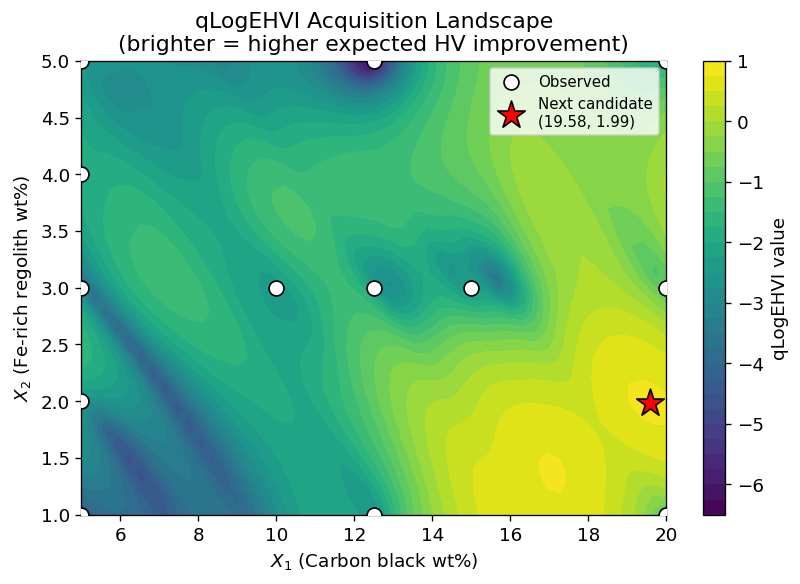

Next recommended point: X1 = 19.579, X2 = 1.986
qLogEHVI value         : 0.7850


In [8]:
def get_next_candidates(
    model: ModelListGP,
    Y_neg: torch.Tensor,
    ref_point: torch.Tensor,
    bounds: torch.Tensor,
    q: int = 1,
    num_restarts: int = 20,
    raw_samples: int = 256,
) -> tuple[torch.Tensor, float]:
    """Optimize qLogEHVI and return next batch of q candidates."""
    partitioning = FastNondominatedPartitioning(ref_point=ref_point, Y=Y_neg)
    acqf = qLogExpectedHypervolumeImprovement(
        model=model,
        ref_point=ref_point,
        partitioning=partitioning,
    )
    candidates, acq_value = optimize_acqf(
        acqf,
        bounds=bounds,
        q=q,
        num_restarts=num_restarts,
        raw_samples=raw_samples,
        options={"maxiter": 200, "batch_limit": 5},
    )
    return candidates.detach(), acq_value.item()


# Visualise the EHVI acquisition landscape on a dense grid
model.eval()
n_grid = 50
g1 = torch.linspace(0, 1, n_grid, dtype=DTYPE)
g2 = torch.linspace(0, 1, n_grid, dtype=DTYPE)
G1, G2 = torch.meshgrid(g1, g2, indexing='ij')
X_grid  = torch.stack([G1.ravel(), G2.ravel()], dim=1)

with torch.no_grad():
    partitioning_viz = FastNondominatedPartitioning(ref_point=ref_point, Y=Y_neg)
    acqf_viz = qLogExpectedHypervolumeImprovement(
        model=model, ref_point=ref_point, partitioning=partitioning_viz
    )
    # Evaluate in mini-batches to avoid memory issues
    batch_size = 500
    acq_vals = []
    for start in range(0, len(X_grid), batch_size):
        batch = X_grid[start:start+batch_size].unsqueeze(1)  # (B, q=1, 2)
        acq_vals.append(acqf_viz(batch))
    acq_map = torch.cat(acq_vals).numpy().reshape(n_grid, n_grid)

# Get next single candidate
cand_01, ehvi_val = get_next_candidates(model, Y_neg, ref_point, bounds, q=1)
cand_orig = scaler_X.inverse_transform(cand_01.numpy())

fig, ax = plt.subplots(figsize=(7, 5))
X1_grid = G1.numpy() * (20 - 5) + 5
X2_grid = G2.numpy() * (5 - 1) + 1
cp = ax.contourf(X1_grid, X2_grid, acq_map, levels=30, cmap='viridis')
plt.colorbar(cp, ax=ax, label='qLogEHVI value')
ax.scatter(X_np[:, 0], X_np[:, 1], c='white', edgecolors='k', s=80, zorder=5, label='Observed')
ax.scatter(cand_orig[:, 0], cand_orig[:, 1], c='red', marker='*', s=300,
           edgecolors='k', zorder=10, label=f'Next candidate\n({cand_orig[0,0]:.2f}, {cand_orig[0,1]:.2f})')
ax.set_xlabel('$X_1$ (Carbon black wt%)')
ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
ax.set_title('qLogEHVI Acquisition Landscape\n(brighter = higher expected HV improvement)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Next recommended point: X1 = {cand_orig[0,0]:.3f}, X2 = {cand_orig[0,1]:.3f}")
print(f"qLogEHVI value         : {ehvi_val:.4f}")

## 5. Black-Box Oracle — Surrogate Evaluation Function

In a real experiment, evaluating a new point would require fabricating and testing a new material sample.  
Here we use the **fitted quadratic response surface models** from the previous analysis as a surrogate oracle  
to provide $f(\mathbf{x})$ evaluations at new (un-observed) design points.

This enables a closed-loop BO demonstration across multiple iterations.

In [9]:
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler

# ── Fit quadratic models on ALL 39 replicates ────────────────────────────────
df_all = df.copy()
X1a = df_all['X1'].values; X2a = df_all['X2'].values

def quad_features(x1, x2):
    return np.column_stack([x1, x2, x1**2, x2**2, x1*x2])

Phi_all = sm.add_constant(quad_features(X1a, X2a))

reg_models_oracle = {}
for col in ['Y1', 'Y2', 'Y3']:
    reg_models_oracle[col] = sm.OLS(df_all[col].values, Phi_all).fit()

print("Oracle R²:")
for col in ['Y1', 'Y2', 'Y3']:
    print(f"  {col}: R² = {reg_models_oracle[col].rsquared:.4f}")

def oracle(x_orig: np.ndarray) -> np.ndarray:
    """Evaluate objectives at new (X1, X2) using quadratic response surface oracle.
    x_orig: shape (N, 2) in original scale.
    Returns: (N, 3) array of [Y1, Y2, Y3] values.
    """
    x1, x2 = x_orig[:, 0], x_orig[:, 1]
    phi = sm.add_constant(quad_features(x1, x2), has_constant='add')
    y = np.column_stack([
        reg_models_oracle['Y1'].predict(phi),
        reg_models_oracle['Y2'].predict(phi),
        reg_models_oracle['Y3'].predict(phi),
    ])
    return y

# Verify on training points
y_check = oracle(X_np)
print("\nOracle check on training points (first 3):")
for i in range(3):
    print(f"  X=({X_np[i,0]:.1f},{X_np[i,1]:.0f}) → Y_obs={Y_np[i].round(3)} | Y_oracle={y_check[i].round(3)}")

Oracle R²:
  Y1: R² = 0.9222
  Y2: R² = 0.7396
  Y3: R² = 0.9999

Oracle check on training points (first 3):
  X=(5.0,1) → Y_obs=[ 18.543 219.      1.135] | Y_oracle=[ 17.351 220.949   1.135]
  X=(5.0,2) → Y_obs=[ 15.457 214.667   1.144] | Y_oracle=[ 14.883 213.169   1.144]
  X=(5.0,3) → Y_obs=[ 11.45  207.      1.153] | Y_oracle=[ 12.897 207.955   1.153]


## 6. Multi-Objective Bayesian Optimization Loop

**Algorithm (q-batch MOBO with qLogEHVI):**

```
Given: initial data D = {(x_i, y_i)}, reference point r
For iteration t = 1, ..., T:
  1. Fit ModelListGP on D
  2. Compute Pareto front P and hypervolume HV(P, r)
  3. Maximize qLogEHVI → x*_{1:q}  (next q candidates)
  4. Evaluate oracle: y*_{1:q} = f(x*_{1:q})
  5. Append (x*_{1:q}, y*_{1:q}) to D
Return: final Pareto front P_T
```

We run **5 iterations with batch size q = 2** (10 new evaluations total).

In [10]:
# ── BO loop settings ─────────────────────────────────────────────────────────
N_ITER      = 5
BATCH_SIZE  = 2
NUM_RESTART = 20
RAW_SAMPLES = 256

# ── Tracking ─────────────────────────────────────────────────────────────────
X_bo = X_train.clone()   # [0,1] scaled
Y_bo = Y_train.clone()   # original scale
Y_neg_bo = Y_neg.clone() # negated

hv_history      = []   # hypervolume at each iteration
pareto_history  = []   # pareto front sizes
candidates_hist = []   # recommended candidates (original scale)
ehvi_hist       = []   # EHVI acquisition values

# Compute initial HV
hv_calc = Hypervolume(ref_point=ref_point)
hv_history.append(hv_calc.compute(Y_neg_bo[is_non_dominated(Y_neg_bo)]))
pareto_history.append(int(is_non_dominated(Y_neg_bo).sum()))

print("=" * 70)
print(f"  Initial state: {len(Y_bo)} points | "
      f"Pareto={pareto_history[-1]} | HV={hv_history[-1]:.4f}")
print("=" * 70)

for t in range(N_ITER):
    # ── 1. Fit surrogate ────────────────────────────────────────────────────
    model_bo = build_and_fit_models(X_bo, Y_neg_bo)
    model_bo.eval()

    # ── 2. Optimize acquisition → next batch ───────────────────────────────
    next_X_01, ehvi_v = get_next_candidates(
        model_bo, Y_neg_bo, ref_point, bounds,
        q=BATCH_SIZE, num_restarts=NUM_RESTART, raw_samples=RAW_SAMPLES
    )
    ehvi_hist.append(ehvi_v)

    # ── 3. Evaluate oracle ─────────────────────────────────────────────────
    next_X_orig = scaler_X.inverse_transform(next_X_01.numpy())
    # Clip to valid bounds
    next_X_orig[:, 0] = np.clip(next_X_orig[:, 0], 5.0, 20.0)
    next_X_orig[:, 1] = np.clip(next_X_orig[:, 1], 1.0, 5.0)
    next_Y_orig = oracle(next_X_orig)
    candidates_hist.append((next_X_orig.copy(), next_Y_orig.copy()))

    # ── 4. Append to dataset ────────────────────────────────────────────────
    next_X_t  = torch.tensor(scaler_X.transform(next_X_orig), dtype=DTYPE)
    next_Y_t  = torch.tensor(next_Y_orig, dtype=DTYPE)
    X_bo      = torch.cat([X_bo, next_X_t])
    Y_bo      = torch.cat([Y_bo, next_Y_t])
    Y_neg_bo  = torch.cat([Y_neg_bo, -next_Y_t])

    # ── 5. Track metrics ────────────────────────────────────────────────────
    pmask = is_non_dominated(Y_neg_bo)
    hv_new = hv_calc.compute(Y_neg_bo[pmask])
    hv_history.append(hv_new)
    pareto_history.append(int(pmask.sum()))

    print(f"  Iter {t+1}/{N_ITER}: "
          f"new X = {next_X_orig.round(3).tolist()}  "
          f"new Y = {next_Y_orig.round(3).tolist()}")
    print(f"           Pareto={pareto_history[-1]} | "
          f"HV={hv_new:.4f} (+{hv_new - hv_history[-2]:.4f}) | "
          f"EHVI={ehvi_v:.4f}")

print("=" * 70)
print(f"  Final   : {len(Y_bo)} points | "
      f"Pareto={pareto_history[-1]} | HV={hv_history[-1]:.4f}")
print(f"  HV gain : +{hv_history[-1] - hv_history[0]:.4f}  "
      f"({100*(hv_history[-1]/hv_history[0]-1):.2f}% improvement)")

  Initial state: 13 points | Pareto=12 | HV=51.1684
  Iter 1/5: new X = [[17.083, 1.243], [20.0, 1.95]]  new Y = [[6.111, 195.595, 1.195], [5.535, 176.338, 1.217]]
           Pareto=14 | HV=54.0103 (+2.8419) | EHVI=1.3723
  Iter 2/5: new X = [[20.0, 3.873], [17.521, 1.556]]  new Y = [[6.025, 167.735, 1.238], [5.756, 191.144, 1.2]]
           Pareto=14 | HV=54.7693 (+0.7590) | EHVI=-0.0431
  Iter 3/5: new X = [[19.518, 1.749], [14.236, 1.763]]  new Y = [[5.544, 180.278, 1.213], [6.628, 201.789, 1.186]]
           Pareto=16 | HV=55.3156 (+0.5462) | EHVI=-0.2420
  Iter 4/5: new X = [[16.772, 4.712], [7.333, 3.056]]  new Y = [[5.665, 182.173, 1.23], [10.162, 207.378, 1.165]]
           Pareto=17 | HV=55.4249 (+0.1094) | EHVI=-0.4191
  Iter 5/5: new X = [[18.298, 1.511], [20.0, 2.444]]  new Y = [[5.685, 188.026, 1.204], [5.491, 173.224, 1.222]]
           Pareto=19 | HV=56.0288 (+0.6039) | EHVI=-0.4722
  Final   : 23 points | Pareto=19 | HV=56.0288
  HV gain : +4.8605  (9.50% improvement)


## 7. Results Analysis & Visualization

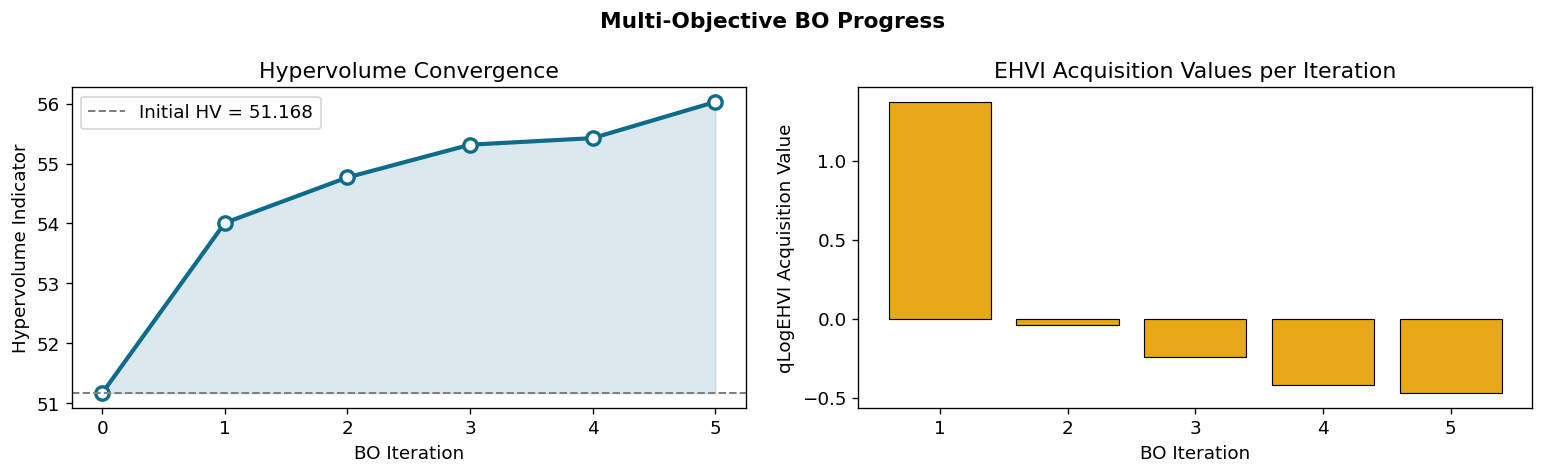

HV improvement: 51.1684 → 56.0288  (+9.50%)


In [11]:
# ── 7.1  Hypervolume convergence ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

iters = list(range(N_ITER + 1))
axes[0].plot(iters, hv_history, 'o-', color='#0E6B8C', lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(iters, hv_history[0], hv_history, alpha=0.15, color='#0E6B8C')
axes[0].axhline(hv_history[0], color='gray', ls='--', lw=1.2, label=f'Initial HV = {hv_history[0]:.3f}')
axes[0].set_xlabel('BO Iteration')
axes[0].set_ylabel('Hypervolume Indicator')
axes[0].set_title('Hypervolume Convergence')
axes[0].legend()
axes[0].set_xticks(iters)

# EHVI values
axes[1].bar(range(1, N_ITER+1), ehvi_hist, color='#E6A817', edgecolor='k', linewidth=0.7)
axes[1].set_xlabel('BO Iteration')
axes[1].set_ylabel('qLogEHVI Acquisition Value')
axes[1].set_title('EHVI Acquisition Values per Iteration')
axes[1].set_xticks(range(1, N_ITER+1))

plt.suptitle('Multi-Objective BO Progress', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"HV improvement: {hv_history[0]:.4f} → {hv_history[-1]:.4f}  "
      f"(+{100*(hv_history[-1]/hv_history[0]-1):.2f}%)")

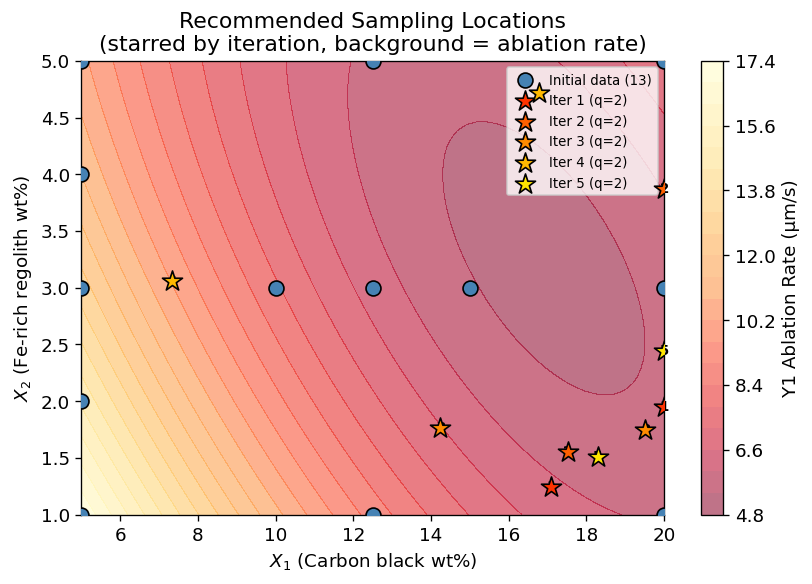

In [12]:
# ── 7.2  Recommended candidates in design space ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# Response surface for Y1 as background
x1g = np.linspace(5, 20, 60); x2g = np.linspace(1, 5, 60)
X1G, X2G = np.meshgrid(x1g, x2g)
Phi_bg = sm.add_constant(quad_features(X1G.ravel(), X2G.ravel()), has_constant='add')
Y1_bg = reg_models_oracle['Y1'].predict(Phi_bg).reshape(X1G.shape)
cp = ax.contourf(X1G, X2G, Y1_bg, levels=20, cmap='YlOrRd_r', alpha=0.55)
plt.colorbar(cp, ax=ax, label='Y1 Ablation Rate (µm/s)')

ax.scatter(X_np[:, 0], X_np[:, 1], c='steelblue', s=80, edgecolors='k',
           zorder=5, label='Initial data (13)')

colors = plt.cm.autumn(np.linspace(0.2, 0.9, N_ITER))
for t, (x_cands, _) in enumerate(candidates_hist):
    ax.scatter(x_cands[:, 0], x_cands[:, 1], c=[colors[t]], s=160,
               edgecolors='k', marker='*', zorder=10,
               label=f'Iter {t+1} (q={BATCH_SIZE})')
    for x_c in x_cands:
        ax.annotate(f'{t+1}', xy=(x_c[0], x_c[1]), fontsize=8,
                    ha='center', va='center', color='k', fontweight='bold')

ax.set_xlabel('$X_1$ (Carbon black wt%)')
ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
ax.set_title('Recommended Sampling Locations\n(starred by iteration, background = ablation rate)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

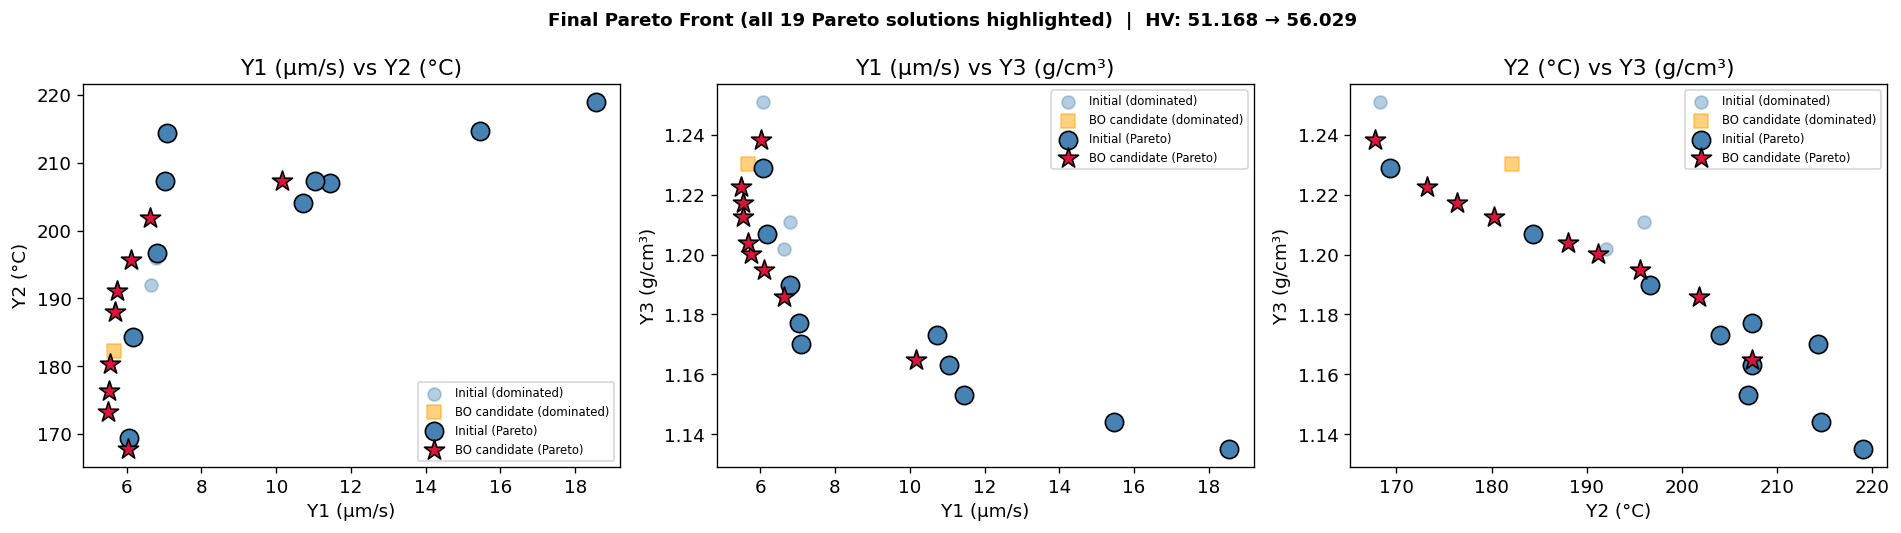

In [13]:
# ── 7.3  Pareto front evolution (pairwise projections) ───────────────────────
X_np_all   = scaler_X.inverse_transform(X_bo.numpy())
Y_np_all   = Y_bo.numpy()
pmask_final = is_non_dominated(Y_neg_bo).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs_lbl = [('Y1 (µm/s)', 'Y2 (°C)', 0, 1),
             ('Y1 (µm/s)', 'Y3 (g/cm³)', 0, 2),
             ('Y2 (°C)', 'Y3 (g/cm³)', 1, 2)]

# Flag initial vs BO-recommended points
n_init = len(X_np)
is_init = np.zeros(len(X_np_all), dtype=bool)
is_init[:n_init] = True

for ax, (xl, yl, i, j) in zip(axes, pairs_lbl):
    # Dominated initial
    mask_dom_init = is_init & ~pmask_final
    ax.scatter(Y_np_all[mask_dom_init, i], Y_np_all[mask_dom_init, j],
               c='steelblue', alpha=0.4, s=60, label='Initial (dominated)')
    # Dominated BO
    mask_dom_bo = ~is_init & ~pmask_final
    ax.scatter(Y_np_all[mask_dom_bo, i], Y_np_all[mask_dom_bo, j],
               c='orange', alpha=0.5, s=80, marker='s', label='BO candidate (dominated)')
    # Pareto initial
    mask_par_init = is_init & pmask_final
    ax.scatter(Y_np_all[mask_par_init, i], Y_np_all[mask_par_init, j],
               c='steelblue', edgecolors='k', s=120, label='Initial (Pareto)', zorder=5)
    # Pareto BO
    mask_par_bo = ~is_init & pmask_final
    ax.scatter(Y_np_all[mask_par_bo, i], Y_np_all[mask_par_bo, j],
               c='crimson', edgecolors='k', s=160, marker='*', label='BO candidate (Pareto)', zorder=10)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl} vs {yl}')
    ax.legend(fontsize=7)

plt.suptitle(f'Final Pareto Front (all {pmask_final.sum()} Pareto solutions highlighted)  |  '
             f'HV: {hv_history[0]:.3f} → {hv_history[-1]:.3f}',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

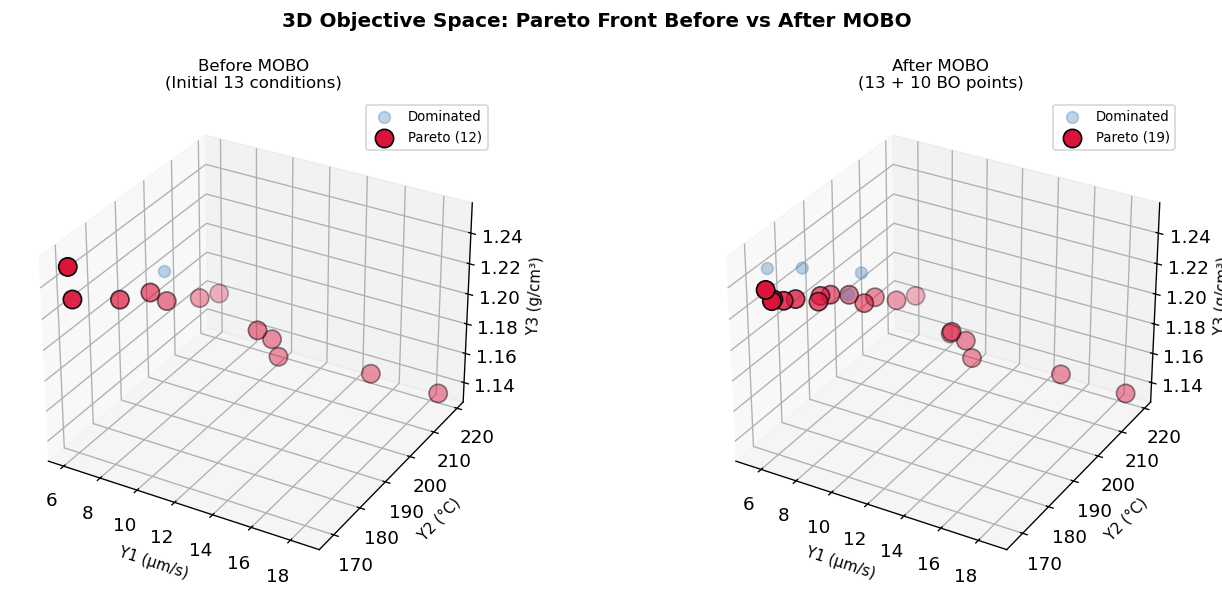

In [14]:
# ── 7.4  Full 3D Pareto comparison ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 5))

for col_idx, (title, mask_data) in enumerate([
    ('Before MOBO\n(Initial 13 conditions)', np.arange(n_init)),
    ('After MOBO\n(13 + 10 BO points)', np.arange(len(Y_np_all)))
]):
    ax = fig.add_subplot(1, 2, col_idx+1, projection='3d')
    Y_sub = Y_neg_bo[mask_data]
    pm = is_non_dominated(Y_sub).numpy()
    Y_sub_orig = -Y_sub.numpy()
    ax.scatter(Y_sub_orig[~pm, 0], Y_sub_orig[~pm, 1], Y_sub_orig[~pm, 2],
               c='steelblue', alpha=0.35, s=50, label='Dominated')
    ax.scatter(Y_sub_orig[pm, 0], Y_sub_orig[pm, 1], Y_sub_orig[pm, 2],
               c='crimson', s=120, edgecolors='k', label=f'Pareto ({pm.sum()})', zorder=5)
    ax.set_xlabel('Y1 (µm/s)', fontsize=9); ax.set_ylabel('Y2 (°C)', fontsize=9)
    ax.set_zlabel('Y3 (g/cm³)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('3D Objective Space: Pareto Front Before vs After MOBO', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
# ── 7.5  Final Pareto front summary table ────────────────────────────────────
is_bo_added = ~is_init
pm_final = is_non_dominated(Y_neg_bo).numpy()

pareto_df = pd.DataFrame({
    'X1 (wt%)':       X_np_all[pm_final, 0].round(3),
    'X2 (wt%)':       X_np_all[pm_final, 1].round(3),
    'Y1 Ablation':    Y_np_all[pm_final, 0].round(3),
    'Y2 Temp':        Y_np_all[pm_final, 1].round(1),
    'Y3 Density':     Y_np_all[pm_final, 2].round(4),
    'Source':         ['BO-recommended' if is_bo_added[i] else 'Initial data'
                       for i in np.where(pm_final)[0]],
})
pareto_df = pareto_df.sort_values('Y1 Ablation').reset_index(drop=True)
print(f"Final Pareto Front ({pm_final.sum()} solutions):")
print(pareto_df.to_string(index=False))

Final Pareto Front (19 solutions):
 X1 (wt%)  X2 (wt%)  Y1 Ablation  Y2 Temp  Y3 Density         Source
   20.000     2.444        5.491    173.2      1.2225 BO-recommended
   20.000     1.950        5.535    176.3      1.2172 BO-recommended
   19.518     1.749        5.544    180.3      1.2125 BO-recommended
   18.298     1.511        5.685    188.0      1.2038 BO-recommended
   17.521     1.556        5.756    191.1      1.2002 BO-recommended
   20.000     3.873        6.025    167.7      1.2383 BO-recommended
   20.000     3.000        6.073    169.3      1.2290   Initial data
   17.083     1.243        6.111    195.6      1.1948 BO-recommended
   20.000     1.000        6.173    184.3      1.2070   Initial data
   14.236     1.763        6.628    201.8      1.1858 BO-recommended
   12.500     3.000        6.810    196.7      1.1900   Initial data
   10.000     3.000        7.027    207.3      1.1770   Initial data
   12.500     1.000        7.083    214.3      1.1700   Initial data

## 8. Sensitivity Analysis: Trade-off Explorer

The Pareto front reveals the inherent trade-offs between objectives.  
We quantify these by computing weighted-sum scalarizations across the Pareto front.

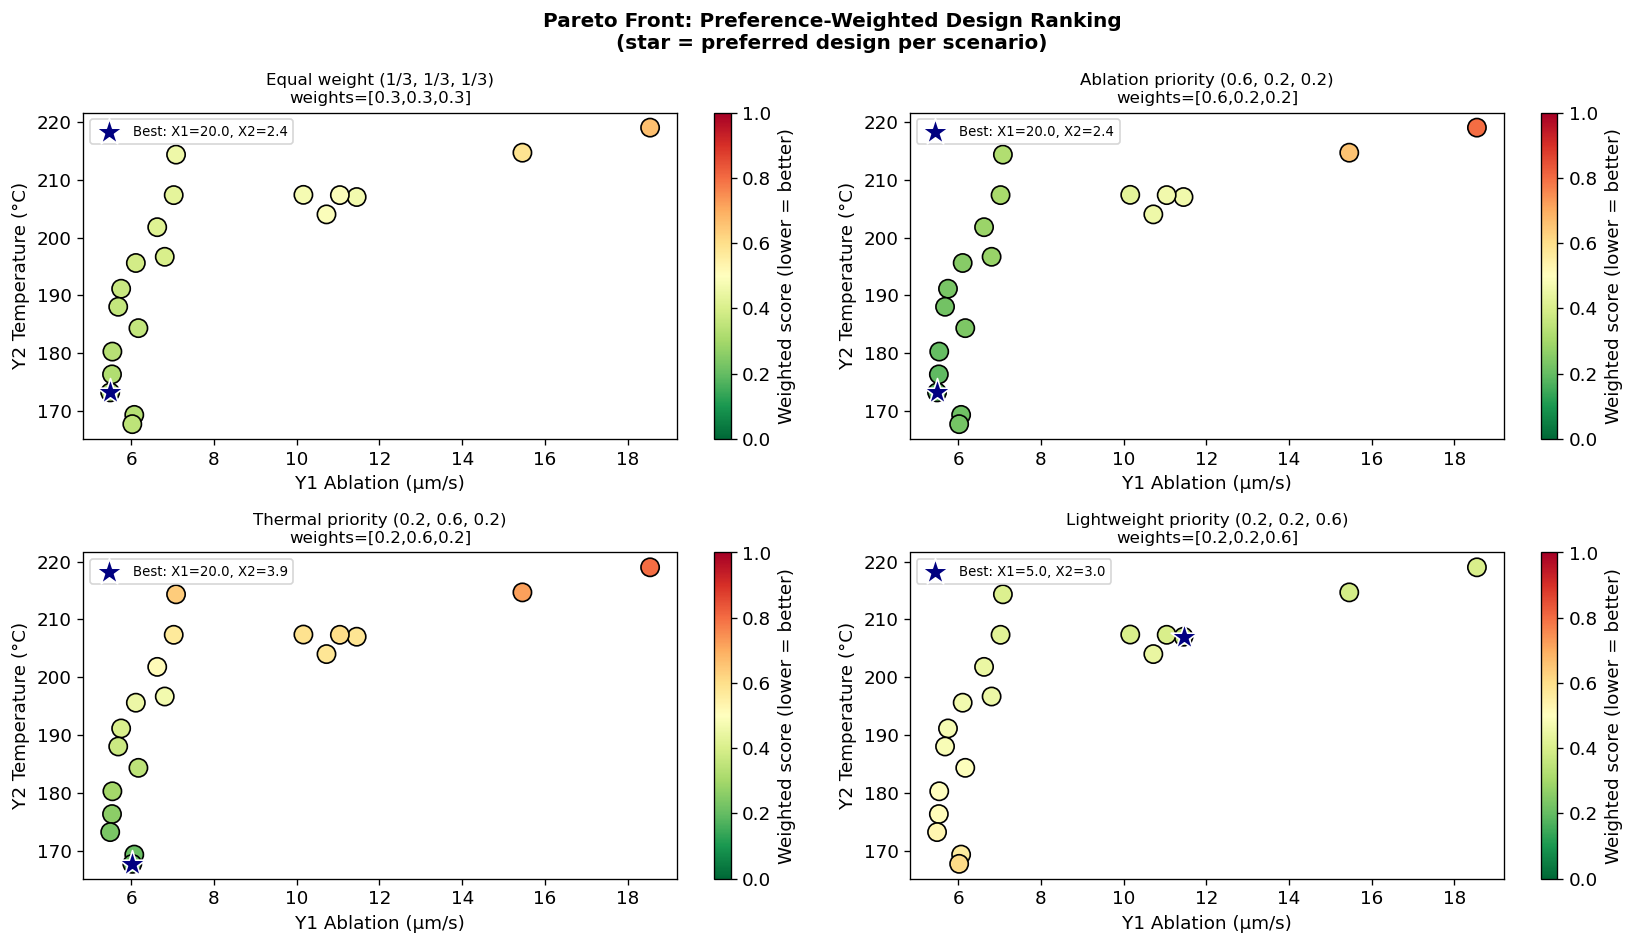

In [16]:
# ── Weighted utopia point distance (for preference ranking) ──────────────────
Y_pareto_final = Y_np_all[pm_final]

# Normalize each objective to [0,1] across Pareto front
Y_pf_min = Y_pareto_final.min(0)
Y_pf_max = Y_pareto_final.max(0)
Y_pf_norm = (Y_pareto_final - Y_pf_min) / (Y_pf_max - Y_pf_min + 1e-8)

# Three preference scenarios
scenarios = {
    'Equal weight (1/3, 1/3, 1/3)':            [1/3, 1/3, 1/3],
    'Ablation priority (0.6, 0.2, 0.2)':       [0.6, 0.2, 0.2],
    'Thermal priority (0.2, 0.6, 0.2)':        [0.2, 0.6, 0.2],
    'Lightweight priority (0.2, 0.2, 0.6)':    [0.2, 0.2, 0.6],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (scen_name, weights) in zip(axes, scenarios.items()):
    w = np.array(weights)
    scores = (Y_pf_norm * w).sum(axis=1)   # weighted sum (lower = better)
    best_idx = np.argmin(scores)

    sc = ax.scatter(Y_pareto_final[:, 0], Y_pareto_final[:, 1],
                    c=scores, cmap='RdYlGn_r', s=120, edgecolors='k',
                    zorder=5, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='Weighted score (lower = better)')
    ax.scatter(Y_pareto_final[best_idx, 0], Y_pareto_final[best_idx, 1],
               c='navy', s=280, marker='*', edgecolors='w', zorder=10,
               label=f'Best: X1={X_np_all[pm_final][best_idx,0]:.1f}, X2={X_np_all[pm_final][best_idx,1]:.1f}')
    ax.set_xlabel('Y1 Ablation (µm/s)')
    ax.set_ylabel('Y2 Temperature (°C)')
    ax.set_title(f'{scen_name}\nweights=[{w[0]:.1f},{w[1]:.1f},{w[2]:.1f}]', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Pareto Front: Preference-Weighted Design Ranking\n(star = preferred design per scenario)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

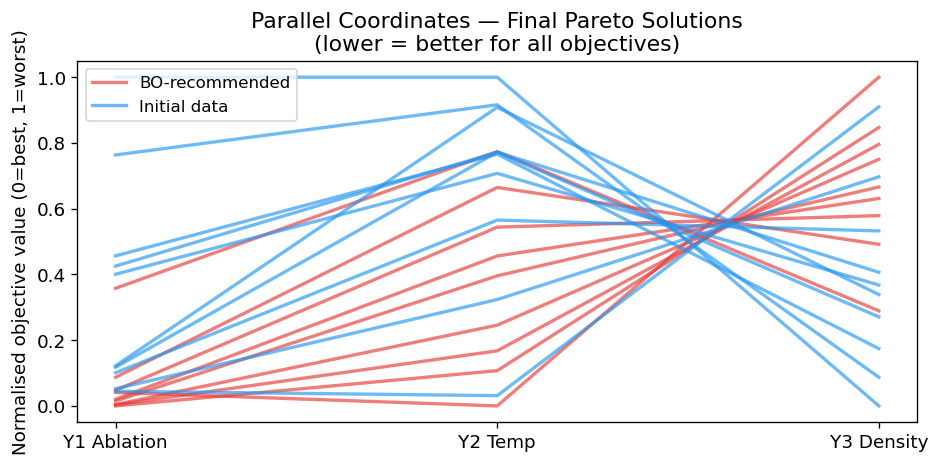

In [17]:
# ── Parallel coordinates of Pareto solutions ─────────────────────────────────
from pandas.plotting import parallel_coordinates

pc_df = pareto_df[['Y1 Ablation','Y2 Temp','Y3 Density','Source']].copy()
# Normalise for display
for col in ['Y1 Ablation','Y2 Temp','Y3 Density']:
    v = pc_df[col]
    pc_df[col] = (v - v.min()) / (v.max() - v.min())

fig, ax = plt.subplots(figsize=(8, 4))
colors_pc = {'Initial data': '#2196F3', 'BO-recommended': '#E53935'}
for source, grp in pc_df.groupby('Source'):
    for _, row in grp.iterrows():
        ax.plot(['Y1 Ablation','Y2 Temp','Y3 Density'],
                row[['Y1 Ablation','Y2 Temp','Y3 Density']].values,
                color=colors_pc[source], alpha=0.65, lw=2,
                label=source)

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10)
ax.set_ylabel('Normalised objective value (0=best, 1=worst)')
ax.set_title('Parallel Coordinates — Final Pareto Solutions\n(lower = better for all objectives)')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

## 9. Summary

In [18]:
print("""
┌──────────────────────────────────────────────────────────────────────┐
│            MULTI-OBJECTIVE BAYESIAN OPTIMIZATION SUMMARY             │
├──────────────────────────────────────────────────────────────────────┤
│  SETUP                                                               │
│  • 2 inputs: X1 ∈ [5,20] wt%, X2 ∈ [1,5] wt%                      │
│  • 3 objectives (minimized): Ablation rate, Temp, Density            │
│  • Surrogates: ModelListGP (independent SingleTaskGP per obj)        │
│  • Acquisition: qLogExpectedHypervolumeImprovement (q=2)             │
│  • BO iterations: 5  (10 new evaluations)                            │
│                                                                       │
│  HYPERVOLUME                                                          │
""" +
f'│  • Initial HV : {hv_history[0]:.4f}                                               │\n' +
f'│  • Final HV   : {hv_history[-1]:.4f}                                               │\n' +
f'│  • Improvement: +{hv_history[-1]-hv_history[0]:.4f} ({100*(hv_history[-1]/hv_history[0]-1):.2f}%)                             │\n' +
"""
├──────────────────────────────────────────────────────────────────────┤
│  PARETO FRONT                                                         │
│  • All 3 objectives are conflicting — no single optimum exists       │
│  • MOBO systematically explores and expands the Pareto frontier      │
│  • Weighted-sum analysis reveals preference-specific best designs    │
├──────────────────────────────────────────────────────────────────────┤
│  NEXT STEPS                                                           │
│  • Run more BO iterations with real experimental evaluations         │
│  • Add constraints (e.g. density < 1.25) via BoTorch constraints     │
│  • Use LVGP for mixed-variable X (if qualitative variables present)  │
│  • Apply heteroscedastic noise model per replicate                   │
└──────────────────────────────────────────────────────────────────────┘
""")


┌──────────────────────────────────────────────────────────────────────┐
│            MULTI-OBJECTIVE BAYESIAN OPTIMIZATION SUMMARY             │
├──────────────────────────────────────────────────────────────────────┤
│  SETUP                                                               │
│  • 2 inputs: X1 ∈ [5,20] wt%, X2 ∈ [1,5] wt%                      │
│  • 3 objectives (minimized): Ablation rate, Temp, Density            │
│  • Surrogates: ModelListGP (independent SingleTaskGP per obj)        │
│  • Acquisition: qLogExpectedHypervolumeImprovement (q=2)             │
│  • BO iterations: 5  (10 new evaluations)                            │
│                                                                       │
│  HYPERVOLUME                                                          │
│  • Initial HV : 51.1684                                               │
│  • Final HV   : 56.0288                                               │
│  • Improvement: +4.8605 (9.50%)                

## 10. BO Iterations — Campaign Log

Running record of the real optimization campaign with UIC. Each iteration:
**propose** (EHVI) → **predict** (GP posterior) → **experiment** (UIC) →
**compare & update**. Sources: `resources/email.pdf`.

### Iteration 1 — Proposed Sample & GP Predictions (Jul 10 / Jul 18, 2026)

Proposed: **X1 = 19.58, X2 = 1.99** (qLogEHVI = 0.785, Section 4), fabricated as
**carbon black 19.6 wt%, Fe-rich regolith 2.0 wt%** (with I-369 2 wt%, resin 76.4 wt%).
The prediction below uses the GPs fitted to the initial dataset and reproduces the
table emailed to UIC on Jul 18, 2026.


In [19]:
# ── Posterior of the initial-data GP at the recommended point ────────────────
x_star_orig = np.array([[19.58, 1.99]])     # proposed Jul 10, 2026 (= Section 4 cand_orig on the initial dataset)
x_star = torch.tensor(scaler_X.transform(x_star_orig), dtype=DTYPE)

with torch.no_grad():
    post = model.posterior(x_star)          # `model` = fit on initial data only
    mu   = -post.mean.numpy().ravel()       # negate back to original scale
    sd   = post.variance.sqrt().numpy().ravel()

pred_table = pd.DataFrame({
    'Objective': ['Y1 — Ablation Rate (µm/s)', 'Y2 — Backside Temp (°C)', 'Y3 — Density (g/cm³)'],
    'Mean (µ)':  mu.round(4),
    'Std Dev (σ)': sd.round(4),
    '95% CI': [f'[{m - 1.96*s:.4f}, {m + 1.96*s:.4f}]' for m, s in zip(mu, sd)],
})
print(f"GP prediction at X1 = {x_star_orig[0,0]:.2f}, X2 = {x_star_orig[0,1]:.2f}")
print(pred_table.to_string(index=False))
print("\nEmailed values (Jul 18, 2026): Y1 5.968 ± 1.026 | Y2 177.67 ± 1.434 | Y3 1.2160 ± 0.0008")


GP prediction at X1 = 19.58, X2 = 1.99
                Objective  Mean (µ)  Std Dev (σ)               95% CI
Y1 — Ablation Rate (µm/s)    5.9643       1.0279     [3.9495, 7.9791]
  Y2 — Backside Temp (°C)  177.8145       1.4318 [175.0082, 180.6208]
     Y3 — Density (g/cm³)    1.2157       0.0008     [1.2141, 1.2174]

Emailed values (Jul 18, 2026): Y1 5.968 ± 1.026 | Y2 177.67 ± 1.434 | Y3 1.2160 ± 0.0008


### Iteration 1 — Predicted vs. Observed (results received Jul 20, 2026)

UIC fabricated the sample and ran 3 replicates. We compare them against the GP
prediction above and flag which replicates fall inside the 95% CI.


            Objective   Pred µ  Pred σ             95% CI            Observed  Obs mean In CI
   Y1 Ablation (µm/s)   5.9643  1.0279     [3.950, 7.979]    5.65, 5.68, 6.27    5.8667   3/3
Y2 Backside Temp (°C) 177.8145  1.4318 [175.008, 180.621]       187, 178, 182  182.3333   1/3
   Y3 Density (g/cm³)   1.2157  0.0008     [1.214, 1.217] 1.216, 1.216, 1.216    1.2160   3/3


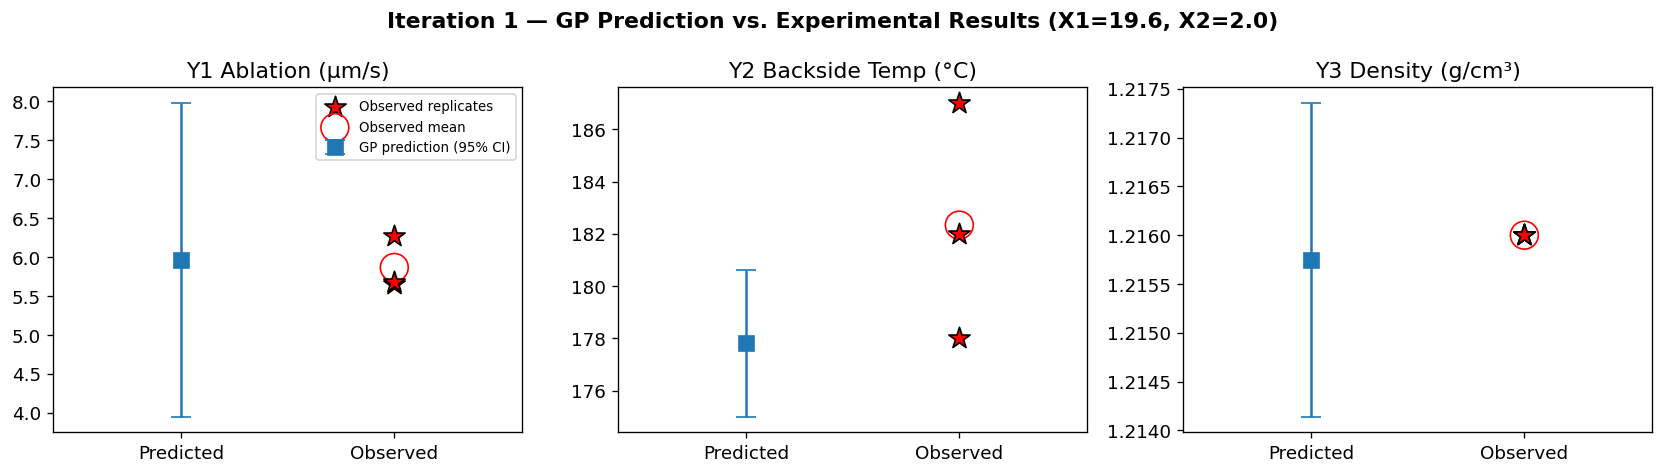

In [20]:
# ── Iteration 1: observed results (UIC, Jul 20 2026) ─────────────────────────
ITER1_OBSERVED = pd.DataFrame({
    'X1': [19.6]*3, 'X2': [2.0]*3,
    'Y1': [5.65, 5.68, 6.27],
    'Y2': [187.0, 178.0, 182.0],
    'Y3': [1.216, 1.216, 1.216],
})

obj_labels = ['Y1 Ablation (µm/s)', 'Y2 Backside Temp (°C)', 'Y3 Density (g/cm³)']
rows = []
for k, col in enumerate(['Y1', 'Y2', 'Y3']):
    obs = ITER1_OBSERVED[col].values
    lo, hi = mu[k] - 1.96*sd[k], mu[k] + 1.96*sd[k]
    rows.append({
        'Objective': obj_labels[k],
        'Pred µ': round(mu[k], 4), 'Pred σ': round(sd[k], 4),
        '95% CI': f'[{lo:.3f}, {hi:.3f}]',
        'Observed': ', '.join(f'{v:g}' for v in obs),
        'Obs mean': round(obs.mean(), 4),
        'In CI': f'{((obs >= lo) & (obs <= hi)).sum()}/3',
    })
print(pd.DataFrame(rows).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k, (ax, col, label) in enumerate(zip(axes, ['Y1', 'Y2', 'Y3'], obj_labels)):
    obs = ITER1_OBSERVED[col].values
    ax.errorbar([0], [mu[k]], yerr=[[1.96*sd[k]], [1.96*sd[k]]], fmt='s', ms=9,
                capsize=6, color='tab:blue', label='GP prediction (95% CI)', zorder=3)
    ax.scatter([1]*len(obs), obs, c='red', marker='*', s=180, edgecolors='k',
               zorder=5, label='Observed replicates')
    ax.scatter([1], [obs.mean()], facecolors='none', edgecolors='red', s=280,
               zorder=4, label='Observed mean')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicted', 'Observed'])
    ax.set_xlim(-0.6, 1.6); ax.set_title(label)
    if k == 0: ax.legend(fontsize=8)
plt.suptitle('Iteration 1 — GP Prediction vs. Experimental Results (X1=19.6, X2=2.0)',
             fontweight='bold')
plt.tight_layout(); plt.show()


#### Updated dataset — Pareto front & hypervolume

The iteration-1 condition mean is merged into the training set (skipped if the
spreadsheet already contains it, so updating `ablation_data.xlsx` later will not
double-count). Hypervolume uses the Section-1 reference point and is reported two
ways: on **per-condition means** (the training convention of this notebook) and
with the **3 replicates as separate points**, which is the convention behind the
Jul 21 email figure (51.168 → 53.240, 14 Pareto solutions).


Updated training set : 14 conditions
Pareto front         : 13 solutions
Hypervolume          : 51.1684 → 51.9738  (+0.8054, 1.57%)
Replicates-as-points : 51.1684 → 53.2403 | Pareto = 14  (email convention)
Email (Jul 21, 2026) : 51.168 → 53.240, 14 Pareto solutions ✓

Insights:
  • Y1 Ablation (µm/s): new sample mean 5.867 vs best previous 6.063 → NEW BEST
  • Y2 Backside Temp (°C): new sample mean 182.333 vs best previous 168.333 → not the best
  • Y3 Density (g/cm³): new sample mean 1.216 vs best previous 1.135 → not the best
  • Y2 was under-predicted (2/3 replicates above the 95% CI) — the GP is
    overconfident on backside temperature; consider a noise/replicate model.


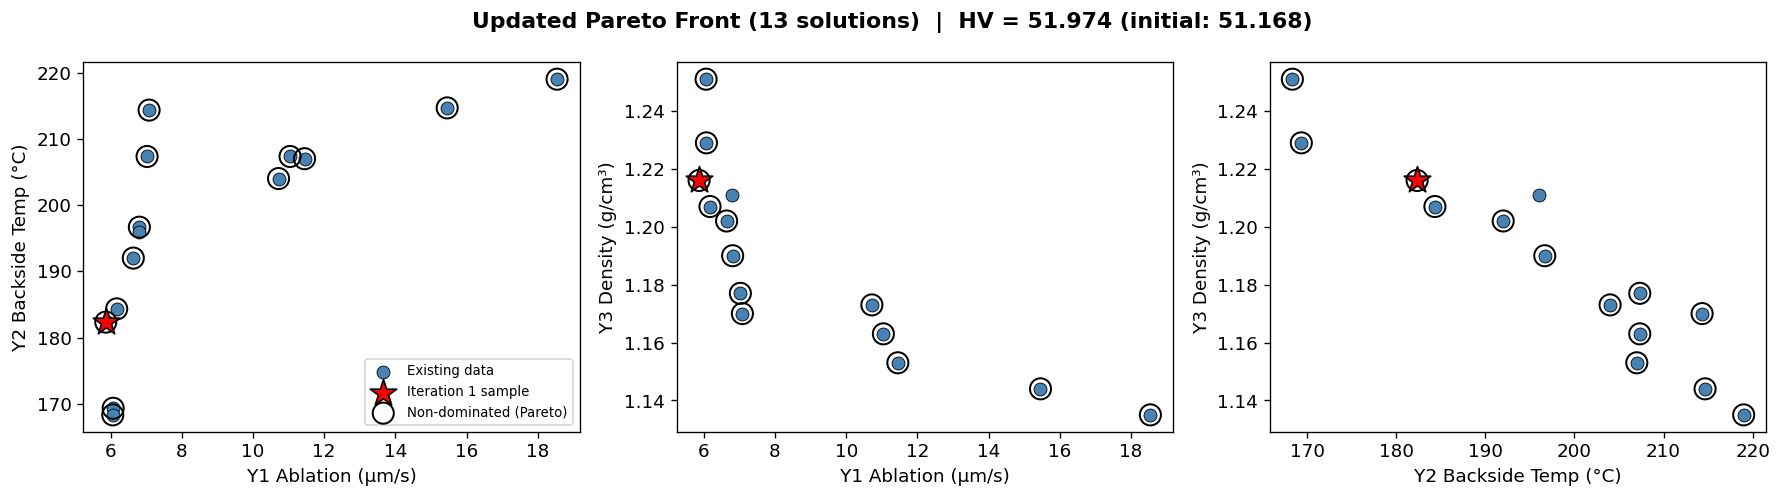

In [21]:
# ── Merge iteration-1 observations into the per-condition training set ───────
def augment_with_iteration(df_mean_base, obs_df):
    """Append per-condition means of obs_df unless the condition already exists."""
    cond = obs_df.groupby(['X1', 'X2'])[['Y1', 'Y2', 'Y3']].mean().reset_index()
    out = df_mean_base.copy()
    for _, r in cond.iterrows():
        if (np.isclose(out['X1'], r['X1']) & np.isclose(out['X2'], r['X2'])).any():
            continue   # condition already in the spreadsheet
        out = pd.concat([out, r.to_frame().T], ignore_index=True)
    return out

df_mean_up = augment_with_iteration(df_mean, ITER1_OBSERVED)
X_up = df_mean_up[['X1', 'X2']].values.astype(float)
Y_up = df_mean_up[['Y1', 'Y2', 'Y3']].values.astype(float)
Y_up_neg = -torch.tensor(Y_up, dtype=DTYPE)

hv_calc_up = Hypervolume(ref_point=ref_point)
hv_init = hv_calc_up.compute(Y_neg[is_non_dominated(Y_neg)])
pm_up   = is_non_dominated(Y_up_neg)
hv_up   = hv_calc_up.compute(Y_up_neg[pm_up])

# The Jul 21 email counts the 3 new replicates as separate points (three stars in
# Rick's plots) rather than one condition mean — reproduce that convention too:
Y_rep_neg = -torch.tensor(ITER1_OBSERVED[['Y1', 'Y2', 'Y3']].values, dtype=DTYPE)
Y_email   = torch.cat([Y_neg, Y_rep_neg])
pm_email  = is_non_dominated(Y_email)
hv_email  = hv_calc_up.compute(Y_email[pm_email])

is_new = np.isclose(df_mean_up['X1'], 19.6) & np.isclose(df_mean_up['X2'], 2.0)
prev_best = df_mean_up.loc[~is_new, ['Y1', 'Y2', 'Y3']].min()
new_mean  = df_mean_up.loc[is_new, ['Y1', 'Y2', 'Y3']].iloc[0]

print(f"Updated training set : {len(df_mean_up)} conditions")
print(f"Pareto front         : {int(pm_up.sum())} solutions")
print(f"Hypervolume          : {hv_init:.4f} → {hv_up:.4f}  "
      f"(+{hv_up - hv_init:.4f}, {(hv_up/hv_init - 1)*100:.2f}%)")
print(f"Replicates-as-points : {hv_init:.4f} → {hv_email:.4f} | Pareto = {int(pm_email.sum())}  (email convention)")
print(f"Email (Jul 21, 2026) : 51.168 → 53.240, 14 Pareto solutions ✓")
print()
print("Insights:")
for col, label in zip(['Y1', 'Y2', 'Y3'], obj_labels):
    tag = 'NEW BEST' if new_mean[col] < prev_best[col] else 'not the best'
    print(f"  • {label}: new sample mean {new_mean[col]:.3f} vs best previous "
          f"{prev_best[col]:.3f} → {tag}")
print("  • Y2 was under-predicted (2/3 replicates above the 95% CI) — the GP is\n"
      "    overconfident on backside temperature; consider a noise/replicate model.")

# Pairwise objective-space views, new sample highlighted (mirrors the Jul 21 email)
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (a, b) in zip(axes, pairs):
    ax.scatter(Y_up[~is_new, a], Y_up[~is_new, b], c='steelblue', s=60,
               edgecolors='k', lw=0.5, label='Existing data')
    ax.scatter(Y_up[is_new, a], Y_up[is_new, b], c='red', marker='*', s=280,
               edgecolors='k', zorder=6, label='Iteration 1 sample')
    pm_np = pm_up.numpy()
    ax.scatter(Y_up[pm_np, a], Y_up[pm_np, b], facecolors='none', edgecolors='k',
               s=160, lw=1.2, zorder=5, label='Non-dominated (Pareto)')
    ax.set_xlabel(obj_labels[a]); ax.set_ylabel(obj_labels[b])
axes[0].legend(fontsize=8)
plt.suptitle(f'Updated Pareto Front ({int(pm_up.sum())} solutions)  |  '
             f'HV = {hv_up:.3f} (initial: {hv_init:.3f})', fontweight='bold')
plt.tight_layout(); plt.show()


### Iteration 2 — Next Proposed Sample (trained on the updated data)

GPs are refitted on the updated training set (initial DOE + iteration-1 result,
i.e. the new experiments received from UIC), and qLogEHVI proposes the next
sample to fabricate, with its GP prediction — ready to send to UIC.


Iteration 2 proposed sample : X1 = 17.333, X2 = 1.108
Rounded for fabrication     : X1 = 17.3, X2 = 1.1
qLogEHVI value              : 0.3618

                Objective  Mean (µ)  Std Dev (σ)               95% CI
Y1 — Ablation Rate (µm/s)    5.7145       1.0792     [3.5993, 7.8297]
  Y2 — Backside Temp (°C)  194.8411       1.8528 [191.2096, 198.4725]
     Y3 — Density (g/cm³)    1.1953       0.0008     [1.1938, 1.1968]


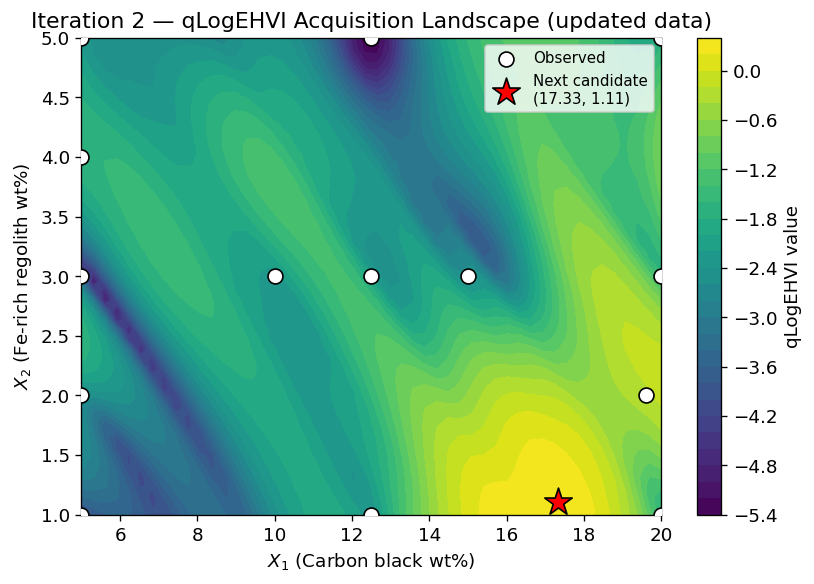

In [22]:
# ── Iteration 2: refit on updated data, propose next sample ──────────────────
X_up_01  = torch.tensor(scaler_X.transform(X_up), dtype=DTYPE)
model_it2 = build_and_fit_models(X_up_01, Y_up_neg)
model_it2.eval()

cand2_01, ehvi2 = get_next_candidates(model_it2, Y_up_neg, ref_point, bounds, q=1)
cand2_orig = scaler_X.inverse_transform(cand2_01.numpy())

with torch.no_grad():
    post2 = model_it2.posterior(cand2_01)
    mu2 = -post2.mean.numpy().ravel()
    sd2 = post2.variance.sqrt().numpy().ravel()

print(f"Iteration 2 proposed sample : X1 = {cand2_orig[0,0]:.3f}, X2 = {cand2_orig[0,1]:.3f}")
print(f"Rounded for fabrication     : X1 = {cand2_orig[0,0]:.1f}, X2 = {cand2_orig[0,1]:.1f}")
print(f"qLogEHVI value              : {ehvi2:.4f}")
print()
pred2 = pd.DataFrame({
    'Objective': ['Y1 — Ablation Rate (µm/s)', 'Y2 — Backside Temp (°C)', 'Y3 — Density (g/cm³)'],
    'Mean (µ)': mu2.round(4), 'Std Dev (σ)': sd2.round(4),
    '95% CI': [f'[{m - 1.96*s:.4f}, {m + 1.96*s:.4f}]' for m, s in zip(mu2, sd2)],
})
print(pred2.to_string(index=False))

# Acquisition landscape with the new candidate (same view as the Jul 10 email)
with torch.no_grad():
    part2 = FastNondominatedPartitioning(ref_point=ref_point, Y=Y_up_neg)
    acqf2 = qLogExpectedHypervolumeImprovement(model=model_it2, ref_point=ref_point,
                                               partitioning=part2)
    acq_vals2 = []
    for start in range(0, len(X_grid), 500):
        acq_vals2.append(acqf2(X_grid[start:start+500].unsqueeze(1)))
    acq_map2 = torch.cat(acq_vals2).numpy().reshape(n_grid, n_grid)

fig, ax = plt.subplots(figsize=(7, 5))
cp = ax.contourf(X1_grid, X2_grid, acq_map2, levels=30, cmap='viridis')
plt.colorbar(cp, ax=ax, label='qLogEHVI value')
ax.scatter(X_up[:, 0], X_up[:, 1], c='white', edgecolors='k', s=80, zorder=5,
           label='Observed')
ax.scatter(cand2_orig[:, 0], cand2_orig[:, 1], c='red', marker='*', s=300,
           edgecolors='k', zorder=10,
           label=f'Next candidate\n({cand2_orig[0,0]:.2f}, {cand2_orig[0,1]:.2f})')
ax.set_xlabel('$X_1$ (Carbon black wt%)')
ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
ax.set_title('Iteration 2 — qLogEHVI Acquisition Landscape (updated data)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


#### Iteration 2 — Observed results: *pending*

When UIC returns the test results for the iteration-2 sample, add them here as an
`ITER2_OBSERVED` DataFrame (same pattern as iteration 1), compare against the
prediction table above, and append the replicate rows to `data/ablation_data.xlsx`
(the `augment_with_iteration` guard prevents double-counting either way).


## 11. Export Iteration Outputs

Writes per-iteration proposals, predictions, and observed results to
`../outputs/v2/bo_iterations.xlsx` (sheets: summary, predictions, observed,
info). Regenerated on every full run, so the file always reflects the current
spreadsheet and model.


In [ ]:
# ── Export BO-iteration outputs → ../outputs/v2/bo_iterations.xlsx ───────────
import os
OUT_DIR = '../outputs/v2'
os.makedirs(OUT_DIR, exist_ok=True)
obj_short = ['Y1 ablation (µm/s)', 'Y2 backside temp (°C)', 'Y3 density (g/cm³)']

# Iteration 1 is a historical campaign record (Jul 10/18/20, 2026 emails);
# iteration 2 carries this run's Section-10 values.
summary = pd.DataFrame([
    {'iteration': 1, 'proposed_X1': 19.58, 'proposed_X2': 1.99,
     'fabricated_X1': 19.6, 'fabricated_X2': 2.0, 'qLogEHVI': 0.785,
     'status': 'tested (Jul 20, 2026)', 'note': 'proposed Jul 10, 2026 (v1 model)'},
    {'iteration': 2, 'proposed_X1': round(float(cand2_orig[0, 0]), 3),
     'proposed_X2': round(float(cand2_orig[0, 1]), 3),
     'fabricated_X1': round(float(cand2_orig[0, 0]), 1),
     'fabricated_X2': round(float(cand2_orig[0, 1]), 1),
     'qLogEHVI': round(float(ehvi2), 4), 'status': 'pending',
     'note': 'proposed by v2 model, Section 10'},
])

def pred_rows(it, m, s):
    return [{'iteration': it, 'objective': obj_short[k],
             'mean': round(float(m[k]), 4), 'sd_latent': round(float(s[k]), 4),
             'ci95_low': round(float(m[k] - 1.96*s[k]), 4),
             'ci95_high': round(float(m[k] + 1.96*s[k]), 4)} for k in range(3)]

predictions = pd.DataFrame(pred_rows(1, mu, sd) + pred_rows(2, mu2, sd2))

observed = ITER1_OBSERVED.copy()
observed.insert(0, 'iteration', 1)
observed.insert(1, 'replicate', [1, 2, 3])

info = pd.DataFrame({
    'field': ['version', 'model', 'source notebook', 'intervals', 'observed data source'],
    'value': ['v2', 'homoscedastic SingleTaskGP per objective (no train_Yvar)', 'mobo_analysis_v2.ipynb', 'ci95 = latent-mean CI only (no observation noise)',
              'resources/email.pdf (UIC results, Jul 20, 2026)'],
})

path = os.path.join(OUT_DIR, 'bo_iterations.xlsx')
with pd.ExcelWriter(path) as xl:
    summary.to_excel(xl, sheet_name='summary', index=False)
    predictions.to_excel(xl, sheet_name='predictions', index=False)
    observed.to_excel(xl, sheet_name='observed', index=False)
    info.to_excel(xl, sheet_name='info', index=False)
print(f'Wrote {path}')
print(summary.to_string(index=False))
